In [70]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mos3santos/netflix/hongkong.csv
/kaggle/input/datasets/mos3santos/netflix/turkey.csv
/kaggle/input/datasets/mos3santos/netflix/south_korea.csv
/kaggle/input/datasets/mos3santos/netflix/spain.csv
/kaggle/input/datasets/mos3santos/netflix/taiwan.csv
/kaggle/input/datasets/mos3santos/netflix/france.csv
/kaggle/input/datasets/mos3santos/netflix/australia.csv
/kaggle/input/datasets/mos3santos/netflix/uk.csv
/kaggle/input/datasets/mos3santos/netflix/india.csv
/kaggle/input/datasets/mos3santos/netflix/mexico.csv
/kaggle/input/datasets/mos3santos/netflix/thailand.csv
/kaggle/input/datasets/mos3santos/netflix/japan.csv
/kaggle/input/datasets/mos3santos/netflix/canada.csv
/kaggle/input/datasets/mos3santos/netflix/egypt.csv


In [71]:
import pandas as pd
df=pd.read_csv("/kaggle/input/datasets/mos3santos/netflix/india.csv",  skiprows=1)
df

,Week,netflix: (India)
0,2015-01-11,4
1,2015-01-18,4
2,2015-01-25,4
3,2015-02-01,4
4,2015-02-08,4
...,...,...
256,2019-12-08,54
257,2019-12-15,58
258,2019-12-22,68
259,2019-12-29,76


In [72]:
df.tail(50)

,Week,netflix: (India)
211,2019-01-27,58
212,2019-02-03,53
213,2019-02-10,50
214,2019-02-17,49
215,2019-02-24,46
216,2019-03-03,45
217,2019-03-10,48
218,2019-03-17,56
219,2019-03-24,47
220,2019-03-31,41


In [73]:
df.describe()

,netflix: (India)
count,261.000000
mean,26.509579
std,22.370072
min,4.000000
25%,9.000000
50%,16.000000
75%,49.000000
max,100.000000


In [74]:
df.columns

Index(['Week', 'netflix: (India)'], dtype='object')

In [75]:
df.isnull().sum()

Week                0
netflix: (India)    0
dtype: int64

In [76]:
df.columns

Index(['Week', 'netflix: (India)'], dtype='object')

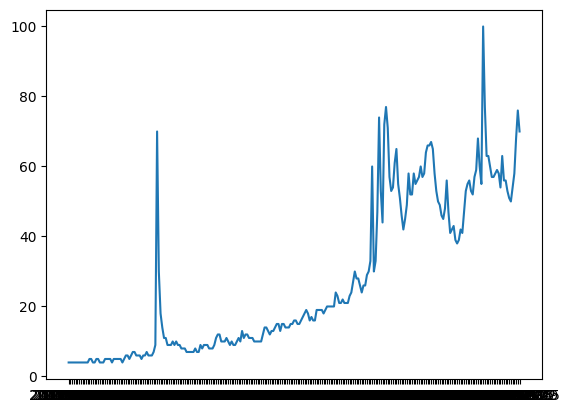

In [77]:
import matplotlib.pyplot as plt
plt.plot(df["Week"],df["netflix: (India)"])
plt.show()

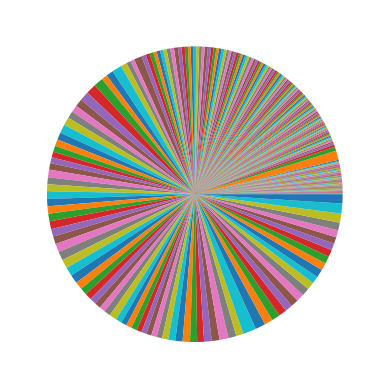

In [82]:
plt.pie(df["netflix: (India)"])
plt.show()

In [85]:
df["Week"].unique

<bound method Series.unique of 0      2015-01-11
1      2015-01-18
2      2015-01-25
3      2015-02-01
4      2015-02-08
          ...    
256    2019-12-08
257    2019-12-15
258    2019-12-22
259    2019-12-29
260    2020-01-05
Name: Week, Length: 261, dtype: object>

In [93]:
df['MA'] = df['netflix: (India)'].rolling(window=10).mean()

from sklearn.linear_model import LinearRegression
import numpy as np

# time ko number me convert
df['t'] = np.arange(len(df))

X = df[['t']]
y = df['netflix: (India)']

model = LinearRegression()
model.fit(X, y)

# future predict (next 20 weeks)
future = np.arange(len(df), len(df)+20).reshape(-1,1)
pred = model.predict(future)


print(pred.round())

[60. 61. 61. 61. 61. 62. 62. 62. 62. 63. 63. 63. 63. 64. 64. 64. 64. 65.
 65. 65.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
